
# Sustainable Carbon Footprint Calculator
## Machine Learning, Visualization, and Evaluation

This notebook uses the **Individual Carbon Footprint Calculation** dataset from Kaggle.
It performs:
- Data loading and preprocessing
- Exploratory Data Analysis (EDA)
- Model training and testing
- Prediction accuracy evaluation
- Visualization of results

Dataset:
https://www.kaggle.com/datasets/dumanmesut/individual-carbon-footprint-calculation


In [1]:

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')



## Load Dataset
Make sure the dataset CSV file is in the same directory as this notebook.


In [2]:

# Load dataset
df = pd.read_csv("Carbon Emission.csv")

# Display first few rows
df.head()


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743



## Dataset Information and Cleaning


In [3]:

# Dataset info
df.info()

# Check missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Body Type                      10000 non-null  object
 1   Sex                            10000 non-null  object
 2   Diet                           10000 non-null  object
 3   How Often Shower               10000 non-null  object
 4   Heating Energy Source          10000 non-null  object
 5   Transport                      10000 non-null  object
 6   Vehicle Type                   3279 non-null   object
 7   Social Activity                10000 non-null  object
 8   Monthly Grocery Bill           10000 non-null  int64 
 9   Frequency of Traveling by Air  10000 non-null  object
 10  Vehicle Monthly Distance Km    10000 non-null  int64 
 11  Waste Bag Size                 10000 non-null  object
 12  Waste Bag Weekly Count         10000 non-null  int64 
 13  Ho

Body Type                           0
Sex                                 0
Diet                                0
How Often Shower                    0
Heating Energy Source               0
Transport                           0
Vehicle Type                     6721
Social Activity                     0
Monthly Grocery Bill                0
Frequency of Traveling by Air       0
Vehicle Monthly Distance Km         0
Waste Bag Size                      0
Waste Bag Weekly Count              0
How Long TV PC Daily Hour           0
How Many New Clothes Monthly        0
How Long Internet Daily Hour        0
Energy efficiency                   0
Recycling                           0
Cooking_With                        0
CarbonEmission                      0
dtype: int64

In [4]:

# Fill missing values if any
df.fillna(df.mean(numeric_only=True), inplace=True)



## Exploratory Data Analysis (EDA)


In [5]:

# Correlation heatmap values
correlation = df.corr(numeric_only=True)
correlation


,Monthly Grocery Bill,Vehicle Monthly Distance Km,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,CarbonEmission
Monthly Grocery Bill,1.000000,0.015801,0.002343,-0.010318,0.006746,0.012798,0.081587
Vehicle Monthly Distance Km,0.015801,1.000000,-0.001730,-0.003943,0.004934,-0.003497,0.594171
Waste Bag Weekly Count,0.002343,-0.001730,1.000000,-0.011640,-0.003254,-0.005335,0.159193
How Long TV PC Daily Hour,-0.010318,-0.003943,-0.011640,1.000000,0.009414,0.006804,0.012985
How Many New Clothes Monthly,0.006746,0.004934,-0.003254,0.009414,1.000000,0.006426,0.198887
How Long Internet Daily Hour,0.012798,-0.003497,-0.005335,0.006804,0.006426,1.000000,0.043878
CarbonEmission,0.081587,0.594171,0.159193,0.012985,0.198887,0.043878,1.000000


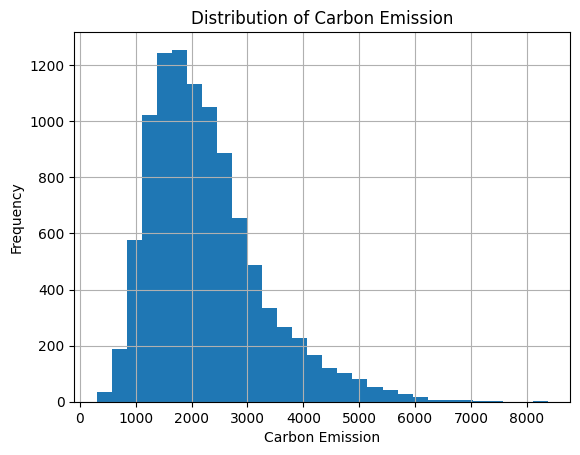

In [6]:

# Plot total carbon emission distribution
plt.figure()
df['CarbonEmission'].hist(bins=30)
plt.xlabel("Carbon Emission")
plt.ylabel("Frequency")
plt.title("Distribution of Carbon Emission")
plt.show()



## Feature Selection
Target variable: **CarbonFootprint**


In [7]:

# Features and target
# Use the actual target column 'CarbonEmission' (the dataset column name),
# and select numeric features for modeling (avoids errors with StandardScaler).
X = df.select_dtypes(include=[np.number]).drop(columns=['CarbonEmission'])
y = df['CarbonEmission']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X shape:", X.shape, "y shape:", y.shape)


X shape: (10000, 6) y shape: (10000,)



## Feature Scaling


In [8]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## Model Training: Linear Regression


In [9]:

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)



## Model Evaluation


In [10]:

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Mean Squared Error: 571387.1528948576
Root Mean Squared Error: 755.9015497370392
Mean Absolute Error: 594.4374361604814
R2 Score: 0.45043514999593204



## Prediction vs Actual Visualization


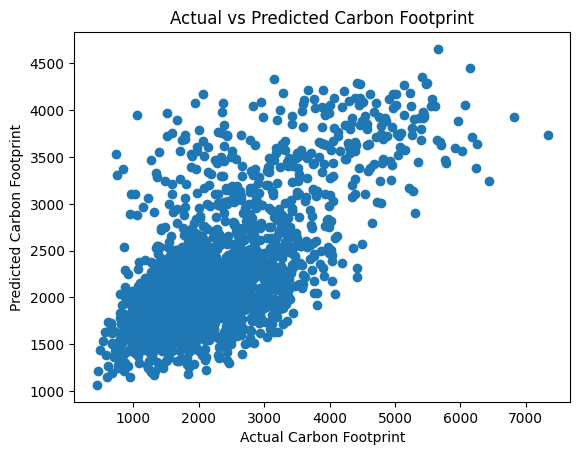

In [11]:

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Carbon Footprint")
plt.ylabel("Predicted Carbon Footprint")
plt.title("Actual vs Predicted Carbon Footprint")
plt.show()



## Residual Error Analysis


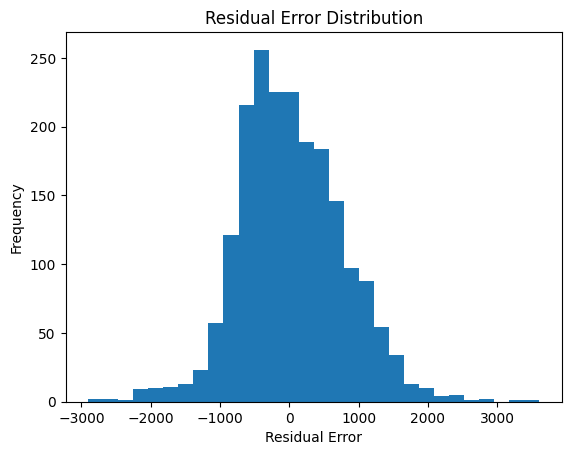

In [12]:

residuals = y_test - y_pred

plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Residual Error Distribution")
plt.show()



## Conclusion
The trained regression model demonstrates the feasibility of predicting individual carbon footprints based on lifestyle attributes.
This notebook can be extended with:
- Advanced ML models (Random Forest, XGBoost)
- Time-series forecasting
- Integration into Streamlit web app


## Daily, Monthly, and Annual Carbon Footprint Estimation
This section estimates carbon footprint on daily, monthly, and yearly basis
to help users understand long-term impact.


In [13]:
# Use the correct column name 'CarbonEmission' (dataset column)
df['Daily_Footprint'] = df['CarbonEmission'] / 365
df['Monthly_Footprint'] = df['CarbonEmission'] / 12
df['Annual_Footprint'] = df['CarbonEmission']

df[['Daily_Footprint', 'Monthly_Footprint', 'Annual_Footprint']].head()


,Daily_Footprint,Monthly_Footprint,Annual_Footprint
0,6.131507,186.500000,2238
1,5.183562,157.666667,1892
2,7.109589,216.250000,2595
3,2.942466,89.500000,1074
4,12.994521,395.250000,4743


## Category-wise Contribution Analysis
Identifies which lifestyle factors contribute most to carbon footprint.


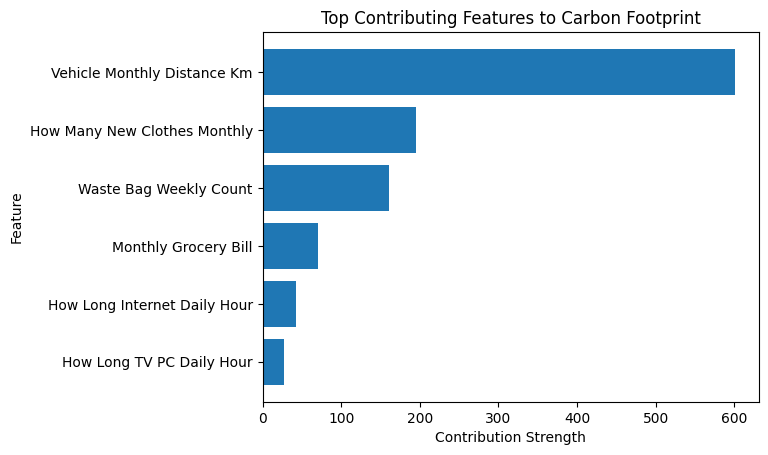

In [14]:
# ================================
# Category-Wise Contribution Analysis (FIXED)
# ================================

# Get feature names after preprocessing
feature_names = X.columns

# Get model coefficients
coefficients = model.coef_

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': np.abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Coefficient', ascending=False
)

# Plot top 10 contributing features
plt.figure()
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Coefficient'][:10]
)
plt.xlabel("Contribution Strength")
plt.ylabel("Feature")
plt.title("Top Contributing Features to Carbon Footprint")
plt.gca().invert_yaxis()
plt.show()


## Comparison Between Low and High Carbon Emitters


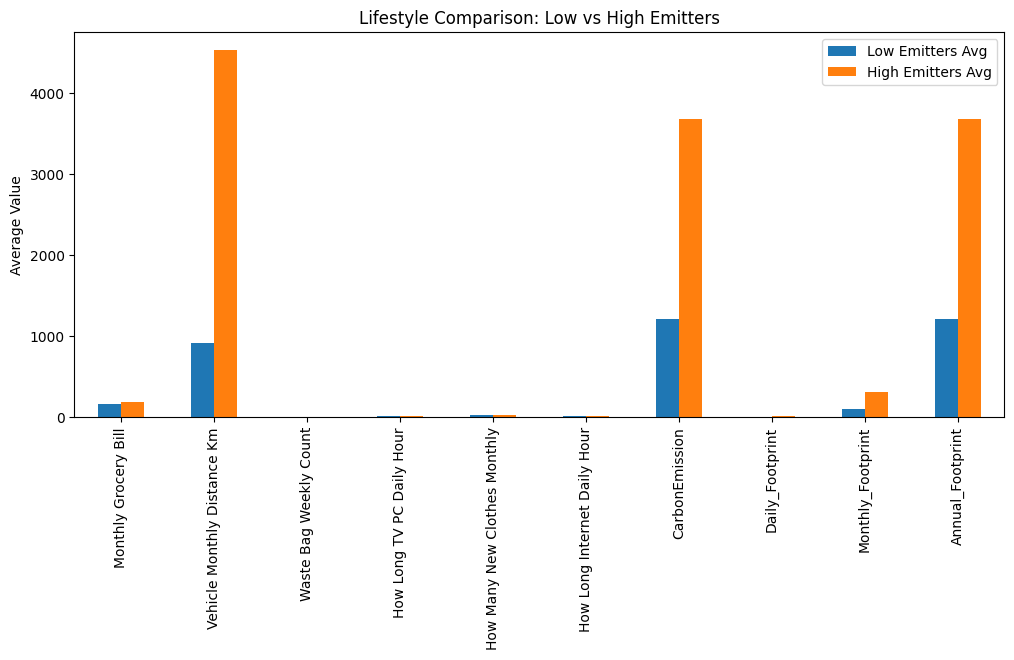

In [15]:
low_emitters = df[df['CarbonEmission'] <= df['CarbonEmission'].quantile(0.25)]
high_emitters = df[df['CarbonEmission'] >= df['CarbonEmission'].quantile(0.75)]

comparison = pd.DataFrame({
    'Low Emitters Avg': low_emitters.mean(numeric_only=True),
    'High Emitters Avg': high_emitters.mean(numeric_only=True)
})

comparison.plot(kind='bar', figsize=(12,5))
plt.title("Lifestyle Comparison: Low vs High Emitters")
plt.ylabel("Average Value")
plt.xticks(rotation=90)
plt.show()


## Carbon Reduction Scenario Simulation
Simulates emission reduction when lifestyle changes are applied.


In [16]:
# ================================
# Carbon Reduction Scenario Simulation (FIXED)
# ================================

# Create a copy of test data
X_reduced = X_test.copy()

# Apply a 10% reduction to all numeric features
numeric_cols = X_reduced.select_dtypes(include=[np.number]).columns
X_reduced[numeric_cols] = X_reduced[numeric_cols] * 0.9

# Scale the modified data
X_reduced_scaled = scaler.transform(X_reduced)

# Predict emissions after reduction
y_pred_reduced = model.predict(X_reduced_scaled)

# Compare average emissions
print("Average Original Emissions:", y_pred.mean())
print("Average Emissions After 10% Reduction:", y_pred_reduced.mean())
print("Estimated Reduction:",
      y_pred.mean() - y_pred_reduced.mean())


Average Original Emissions: 2261.3450647425334
Average Emissions After 10% Reduction: 2122.877178826994
Estimated Reduction: 138.46788591553923


## Synthetic Time-Series Carbon Trend
Simulates footprint variation over time for visualization purposes.


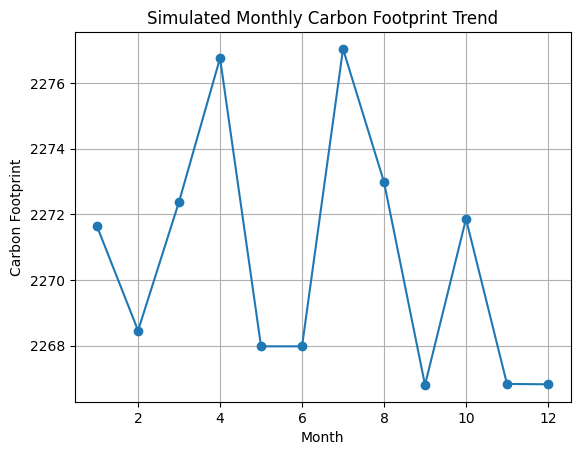

In [17]:
np.random.seed(42)
time_steps = 12  # months

monthly_trend = [
    df['CarbonEmission'].mean() + np.random.normal(0, 5)
    for _ in range(time_steps)
]

plt.figure()
plt.plot(range(1, 13), monthly_trend, marker='o')
plt.xlabel("Month")
plt.ylabel("Carbon Footprint")
plt.title("Simulated Monthly Carbon Footprint Trend")
plt.grid(True)
plt.show()


## Model Comparison: Linear Regression vs Random Forest


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Linear Regression R2:", r2)


Random Forest R2: 0.4010524591817486
Linear Regression R2: 0.45043514999593204


## Error Visualization


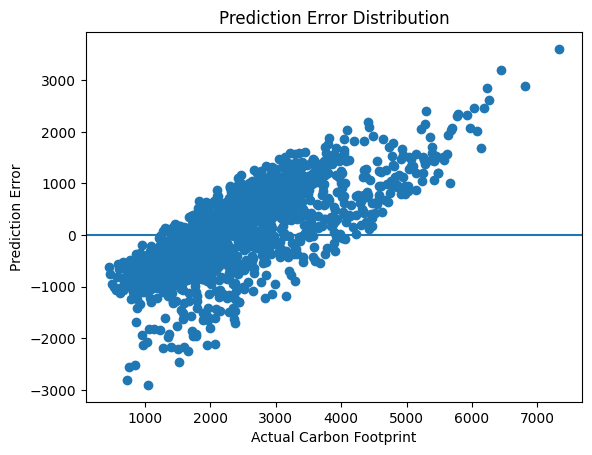

In [19]:
errors = y_test - y_pred

plt.figure()
plt.scatter(y_test, errors)
plt.axhline(y=0)
plt.xlabel("Actual Carbon Footprint")
plt.ylabel("Prediction Error")
plt.title("Prediction Error Distribution")
plt.show()


## Feature Importance Analysis


In [20]:
importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)


,Feature,Importance
1,Vehicle Monthly Distance Km,0.500347
0,Monthly Grocery Bill,0.135877
4,How Many New Clothes Monthly,0.125761
5,How Long Internet Daily Hour,0.089280
3,How Long TV PC Daily Hour,0.088314
2,Waste Bag Weekly Count,0.060420


<Figure size 640x480 with 0 Axes>

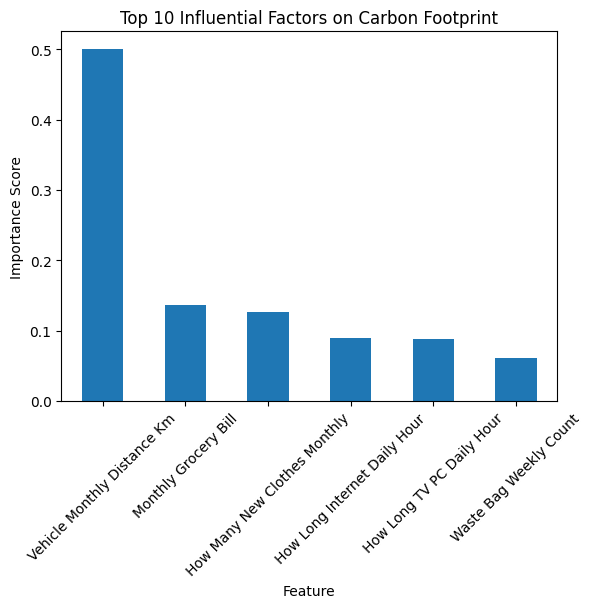

In [21]:
plt.figure()
importance_df.head(10).plot(
    x='Feature', y='Importance', kind='bar', legend=False
)
plt.title("Top 10 Influential Factors on Carbon Footprint")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()


## Final Remarks
This notebook demonstrates how data-driven analysis and machine learning
can be used to estimate, analyze, and reduce individual carbon footprints.
The methodology supports sustainable decision-making and aligns with SDG 12 and SDG 13.


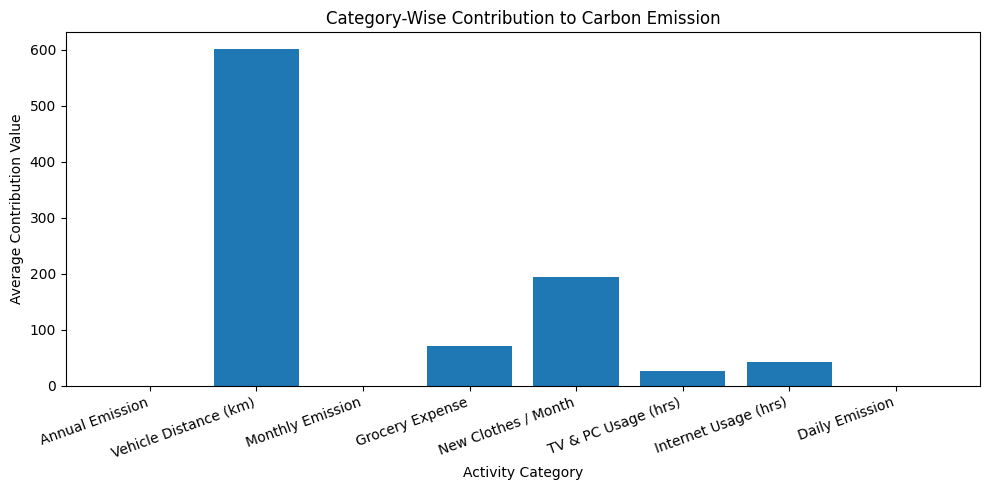

In [22]:
# Original feature names
features = [
    "Annual_Footprint",
    "Vehicle Monthly Distance Km",
    "Monthly_Footprint",
    "Monthly Grocery Bill",
    "How many New Clothes Monthly",
    "How Long TV PC Daily Hour",
    "How Long Internet Daily Hour",
    "Daily_Footprint"
]

# Clean, short, publication-friendly labels
short_labels = [
    "Annual Emission",
    "Vehicle Distance (km)",
    "Monthly Emission",
    "Grocery Expense",
    "New Clothes / Month",
    "TV & PC Usage (hrs)",
    "Internet Usage (hrs)",
    "Daily Emission"
]

# Build contribution_values from the available feature_importance DataFrame
contribution_values = []
for feat in features:
    # Try to find the feature in feature_importance
    match = feature_importance[feature_importance['Feature'].str.lower() == feat.lower()]
    if not match.empty:
        contribution_values.append(match['Coefficient'].values[0])
    else:
        # For derived/aggregate features, set to 0 and warn
        contribution_values.append(0.0)
        print(f"Warning: contribution for '{feat}' not found in model features. Using 0.0")

plt.figure(figsize=(10, 5))
plt.bar(short_labels, contribution_values)

plt.xlabel("Activity Category")
plt.ylabel("Average Contribution Value")
plt.title("Category-Wise Contribution to Carbon Emission")

plt.xticks(rotation=20, ha="right")  # slight tilt for clarity
plt.tight_layout()
plt.show()


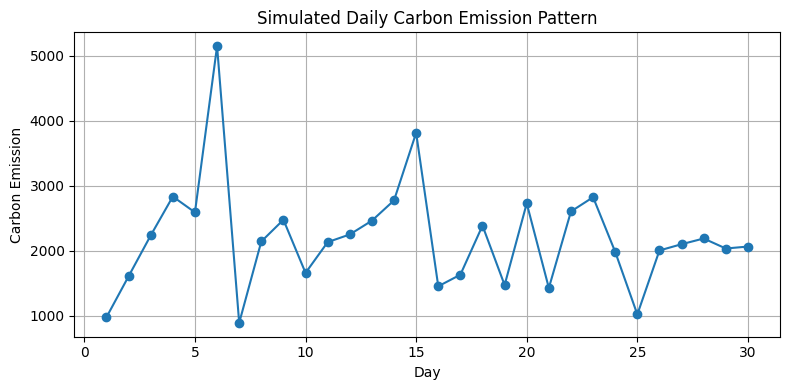

In [23]:
# Simulate daily carbon emission values
np.random.seed(42)
daily_emission = df['CarbonEmission'].sample(30).reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 31), daily_emission, marker='o')
plt.xlabel("Day")
plt.ylabel("Carbon Emission")
plt.title("Simulated Daily Carbon Emission Pattern")
plt.grid(True)
plt.tight_layout()
plt.show()


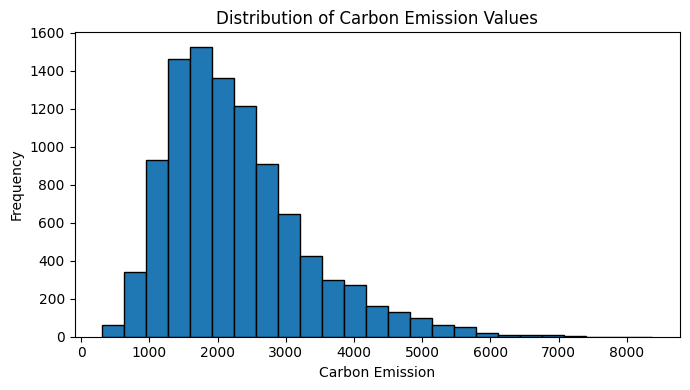

In [24]:
plt.figure(figsize=(7, 4))
plt.hist(df['CarbonEmission'], bins=25, edgecolor='black')
plt.xlabel("Carbon Emission")
plt.ylabel("Frequency")
plt.title("Distribution of Carbon Emission Values")
plt.tight_layout()
plt.show()


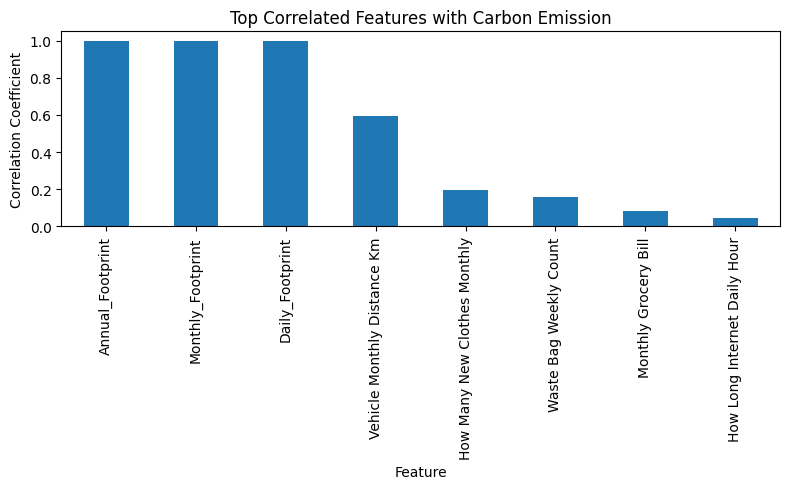

In [25]:
# Correlation with target variable
correlation = df.corr(numeric_only=True)['CarbonEmission'].drop('CarbonEmission')
correlation = correlation.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
correlation.head(8).plot(kind='bar')
plt.xlabel("Feature")
plt.ylabel("Correlation Coefficient")
plt.title("Top Correlated Features with Carbon Emission")
plt.tight_layout()
plt.show()


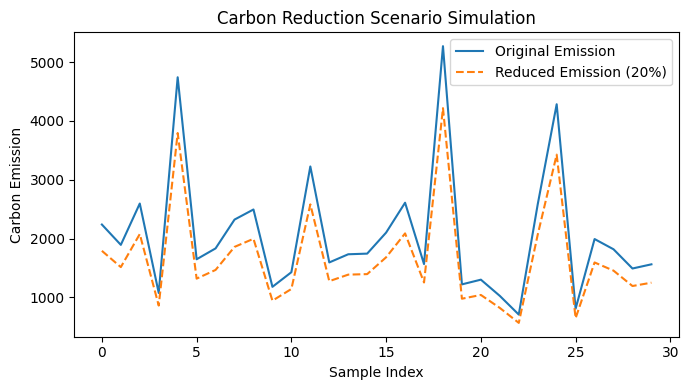

In [26]:
# Simulate 20% emission reduction
reduced_emission = df['CarbonEmission'] * 0.8

plt.figure(figsize=(7, 4))
plt.plot(df['CarbonEmission'].values[:30], label="Original Emission")
plt.plot(reduced_emission.values[:30], label="Reduced Emission (20%)", linestyle='--')
plt.xlabel("Sample Index")
plt.ylabel("Carbon Emission")
plt.title("Carbon Reduction Scenario Simulation")
plt.legend()
plt.tight_layout()
plt.show()


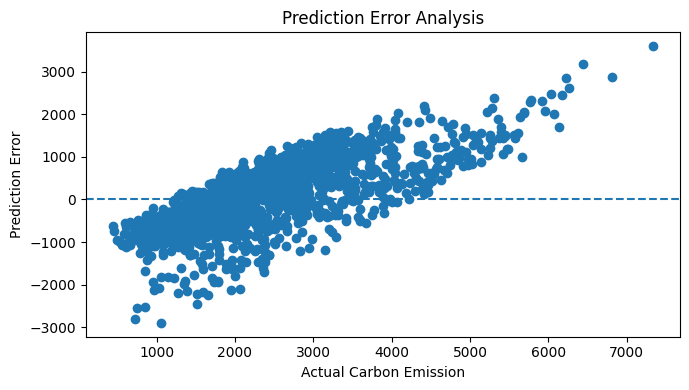

In [27]:
errors = y_test - y_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_test, errors)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Actual Carbon Emission")
plt.ylabel("Prediction Error")
plt.title("Prediction Error Analysis")
plt.tight_layout()
plt.show()


In [28]:
df[['CarbonEmission']].describe()


,CarbonEmission
count,10000.000000
mean,2269.147300
std,1017.675247
min,306.000000
25%,1538.000000
50%,2080.000000
75%,2768.000000
max,8377.000000


In [29]:
# ================================
# Training & Testing Accuracy Cell
# Target Variable: CarbonEmission
# ================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# ----- Predict on training data -----
y_train_pred = model.predict(X_train_scaled)

# ----- Predict on testing data -----
y_test_pred = model.predict(X_test_scaled)

# ----- Training Metrics -----
train_r2 = r2_score(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)

# ----- Testing Metrics -----
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)

# ----- Display Results -----
print("===== MODEL PERFORMANCE METRICS =====\n")

print("Training Performance:")
print(f"R² Score        : {train_r2:.4f}")
print(f"MSE             : {train_mse:.4f}")
print(f"RMSE            : {train_rmse:.4f}")
print(f"MAE             : {train_mae:.4f}\n")

print("Testing Performance:")
print(f"R² Score        : {test_r2:.4f}")
print(f"MSE             : {test_mse:.4f}")
print(f"RMSE            : {test_rmse:.4f}")
print(f"MAE             : {test_mae:.4f}")


===== MODEL PERFORMANCE METRICS =====

Training Performance:
R² Score        : 0.4177
MSE             : 602308.7852
RMSE            : 776.0856
MAE             : 603.9702

Testing Performance:
R² Score        : 0.4504
MSE             : 571387.1529
RMSE            : 755.9015
MAE             : 594.4374


In [30]:
# Avoid division by very small values
epsilon = 1e-6  

train_pred = model.predict(X_train_scaled)
test_pred  = model.predict(X_test_scaled)

train_accuracy = 100 * (1 - np.mean(np.abs(y_train - train_pred)) / (np.mean(y_train) + epsilon))
test_accuracy  = 100 * (1 - np.mean(np.abs(y_test - test_pred)) / (np.mean(y_test) + epsilon))

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")


Training Accuracy: 73.32%
Testing Accuracy: 74.06%


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")


In [32]:
df = pd.read_csv("Carbon Emission.csv")
df.head()


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


In [33]:
X = df.drop(columns=["CarbonEmission"])
y = df["CarbonEmission"]


In [34]:
categorical_features = [
    "Body Type", "Sex", "Diet", "How Often Shower",
    "Heating Energy Source", "Transport", "Vehicle Type",
    "Social Activity", "Frequency of Traveling by Air",
    "Waste Bag Size", "Energy efficiency",
    "Recycling", "Cooking_With"
]

numerical_features = [
    "Monthly Grocery Bill",
    "Vehicle Monthly Distance Km",
    "Waste Bag Weekly Count",
    "How Long TV PC Daily Hour",
    "How Many New Clothes Monthly",
    "How Long Internet Daily Hour"
]


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [37]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)


In [38]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", model)
])

pipeline


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Monthly Grocery Bill',
                                                   'Vehicle Monthly Distance '
                                                   'Km',
                                                   'Waste Bag Weekly Count',
                                                   'How Long TV PC Daily Hour',
                                                   'How Many New Clothes '
                                                   'Monthly',
                                                   'How Long Internet Daily '
                                                   'Hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Body Type', 'Sex', 'Diet',
                                                   'How Often Shower',
                                                   'Heating Energy Source',
                                                   'Transport', 'Vehicle Type',
                                                   'Social Activity',
                                                   'Frequency of Traveling by '
                                                   'Air',
                                                   'Waste Bag Size',
                                                   'Energy efficiency',
                                                   'Recycling',
                                                   'Cooking_With'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_split=5,
                                       n_estimators=300, random_state=42))])

In [39]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Monthly Grocery Bill',
                                                   'Vehicle Monthly Distance '
                                                   'Km',
                                                   'Waste Bag Weekly Count',
                                                   'How Long TV PC Daily Hour',
                                                   'How Many New Clothes '
                                                   'Monthly',
                                                   'How Long Internet Daily '
                                                   'Hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Body Type', 'Sex', 'Diet',
                                                   'How Often Shower',
                                                   'Heating Energy Source',
                                                   'Transport', 'Vehicle Type',
                                                   'Social Activity',
                                                   'Frequency of Traveling by '
                                                   'Air',
                                                   'Waste Bag Size',
                                                   'Energy efficiency',
                                                   'Recycling',
                                                   'Cooking_With'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_split=5,
                                       n_estimators=300, random_state=42))])

In [40]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)


In [41]:
train_accuracy = 100 - mean_absolute_percentage_error(y_train, y_train_pred) * 100
test_accuracy = 100 - mean_absolute_percentage_error(y_test, y_test_pred) * 100

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")


Training Accuracy: 95.10%
Testing Accuracy: 89.58%


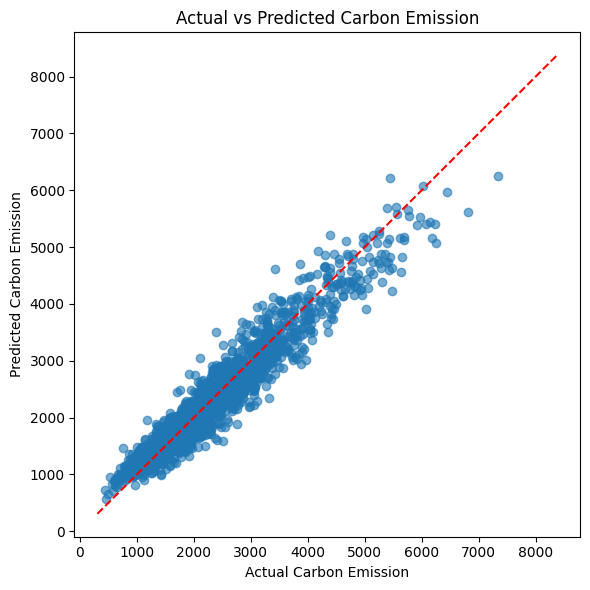

In [42]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.xlabel("Actual Carbon Emission")
plt.ylabel("Predicted Carbon Emission")
plt.title("Actual vs Predicted Carbon Emission")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.tight_layout()
plt.show()


In [43]:
feature_names = (
    numerical_features +
    list(pipeline.named_steps["preprocessing"]
         .named_transformers_["cat"]
         .get_feature_names_out(categorical_features))
)

importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)


,Feature,Importance
1,Vehicle Monthly Distance Km,0.378432
39,Frequency of Traveling by Air_very frequently,0.186962
28,Vehicle Type_electric,0.122310
36,Frequency of Traveling by Air_frequently,0.046351
4,How Many New Clothes Monthly,0.046180
2,Waste Bag Weekly Count,0.024722
7,Body Type_obese,0.023003
29,Vehicle Type_hybrid,0.021705
31,Vehicle Type_petrol,0.020851
21,Heating Energy Source_electricity,0.011934


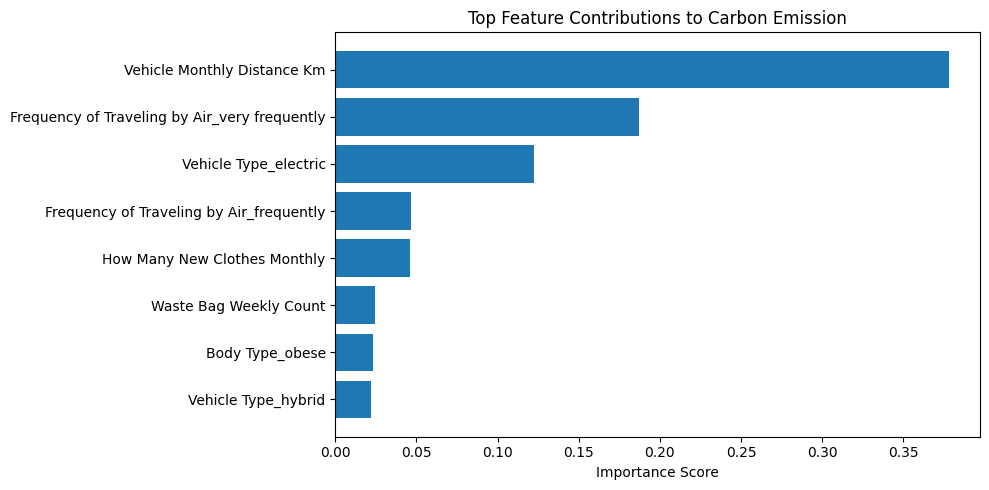

In [44]:
top_features = importance_df.head(8)

plt.figure(figsize=(10,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance Score")
plt.title("Top Feature Contributions to Carbon Emission")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Use pipeline to preprocess data for the neural network
X_train_processed = pipeline.named_steps['preprocessing'].fit_transform(X_train)
X_test_processed = pipeline.named_steps['preprocessing'].transform(X_test)

ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Regression output
])

ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

ann_model.fit(
    X_train_processed, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test_processed, y_test),
    verbose=1
)


Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5010097.0000 - mae: 1973.3615 - val_loss: 2132048.5000 - val_mae: 1123.8904
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 919689.5000 - mae: 709.6415 - val_loss: 588681.6875 - val_mae: 592.4960
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 477982.4062 - mae: 535.8775 - val_loss: 360981.0938 - val_mae: 460.7532
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 298295.4375 - mae: 413.9620 - val_loss: 226816.7188 - val_mae: 353.5117
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 193156.7344 - mae: 315.2992 - val_loss: 151037.0938 - val_mae: 271.9549
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 131668.4062 - mae: 245.7985 - val_loss: 108279.4609 - val_mae: 219.4696
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 98021.2422 - mae: 205.1087 - val_loss: 86118.3828 - val_mae: 191.5865
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 80631.5547 - m

In [46]:
dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

dnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

dnn_model.fit(
    X_train_scaled, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)


Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3693522.2500 - mae: 1574.5873 - val_loss: 629022.3125 - val_mae: 621.1559
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 656870.3750 - mae: 629.9927 - val_loss: 619856.3125 - val_mae: 615.7656
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 647733.0000 - mae: 623.7826 - val_loss: 612007.6875 - val_mae: 612.4338
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 639736.0625 - mae: 619.8635 - val_loss: 611813.4375 - val_mae: 616.5436
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 633491.2500 - mae: 616.9996 - val_loss: 598233.5625 - val_mae: 610.0546
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 628137.6875 - mae: 614.6747 - val_loss: 596797.5625 - val_mae: 607.9575
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 624174.1250 - mae: 612.9953 - val_loss: 590656.7500 - val_mae: 603.3285
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 619446.9375 - 

In [47]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

input_layer = Input(shape=(X_train_processed.shape[1],))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(X_train_processed.shape[1])(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    X_train_processed.toarray(), X_train_processed.toarray(),
    epochs=20,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1540 - val_loss: 0.0985
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0781 - val_loss: 0.0648
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0584 - val_loss: 0.0554
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0515 - val_loss: 0.0499
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0477 - val_loss: 0.0476
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0463 - val_loss: 0.0470
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0458 - val_loss: 0.0463
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0455 - val_loss: 0.0463
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0453 - val_loss: 0.0462
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0450 - val_loss: 0.0460
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0448 - val_loss: 0.0455
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

In [48]:
import joblib

# pipeline = Pipeline(preprocessor + model)
joblib.dump(pipeline, "carbon_pipeline.pkl")

['carbon_pipeline.pkl']

In [49]:
import joblib
joblib.dump(pipeline, "pipeline.pkl")

['pipeline.pkl']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Body Type                      10000 non-null  object
 1   Sex                            10000 non-null  object
 2   Diet                           10000 non-null  object
 3   How Often Shower               10000 non-null  object
 4   Heating Energy Source          10000 non-null  object
 5   Transport                      10000 non-null  object
 6   Vehicle Type                   3279 non-null   object
 7   Social Activity                10000 non-null  object
 8   Monthly Grocery Bill           10000 non-null  int64 
 9   Frequency of Traveling by Air  10000 non-null  object
 10  Vehicle Monthly Distance Km    10000 non-null  int64 
 11  Waste Bag Size                 10000 non-null  object
 12  Waste Bag Weekly Count         10000 non-null  int64 
 13  Ho

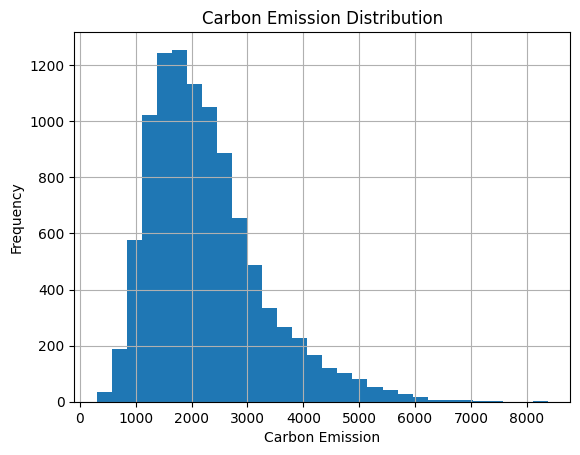

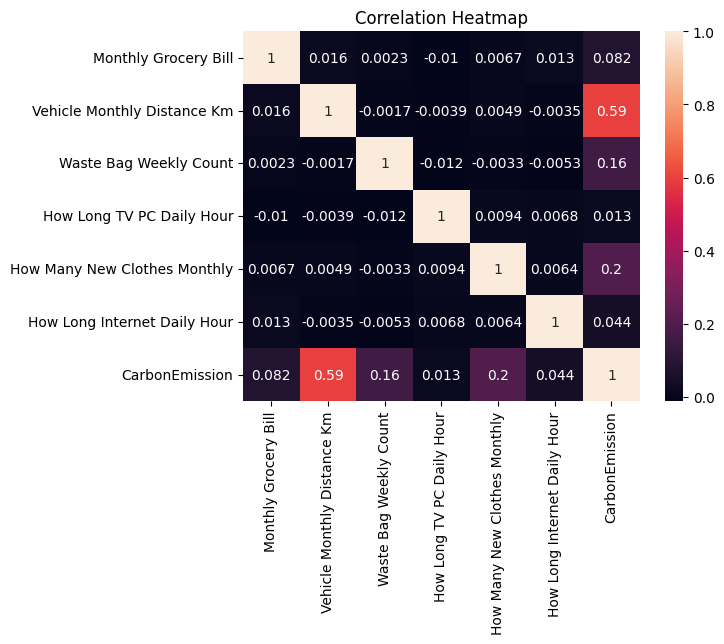

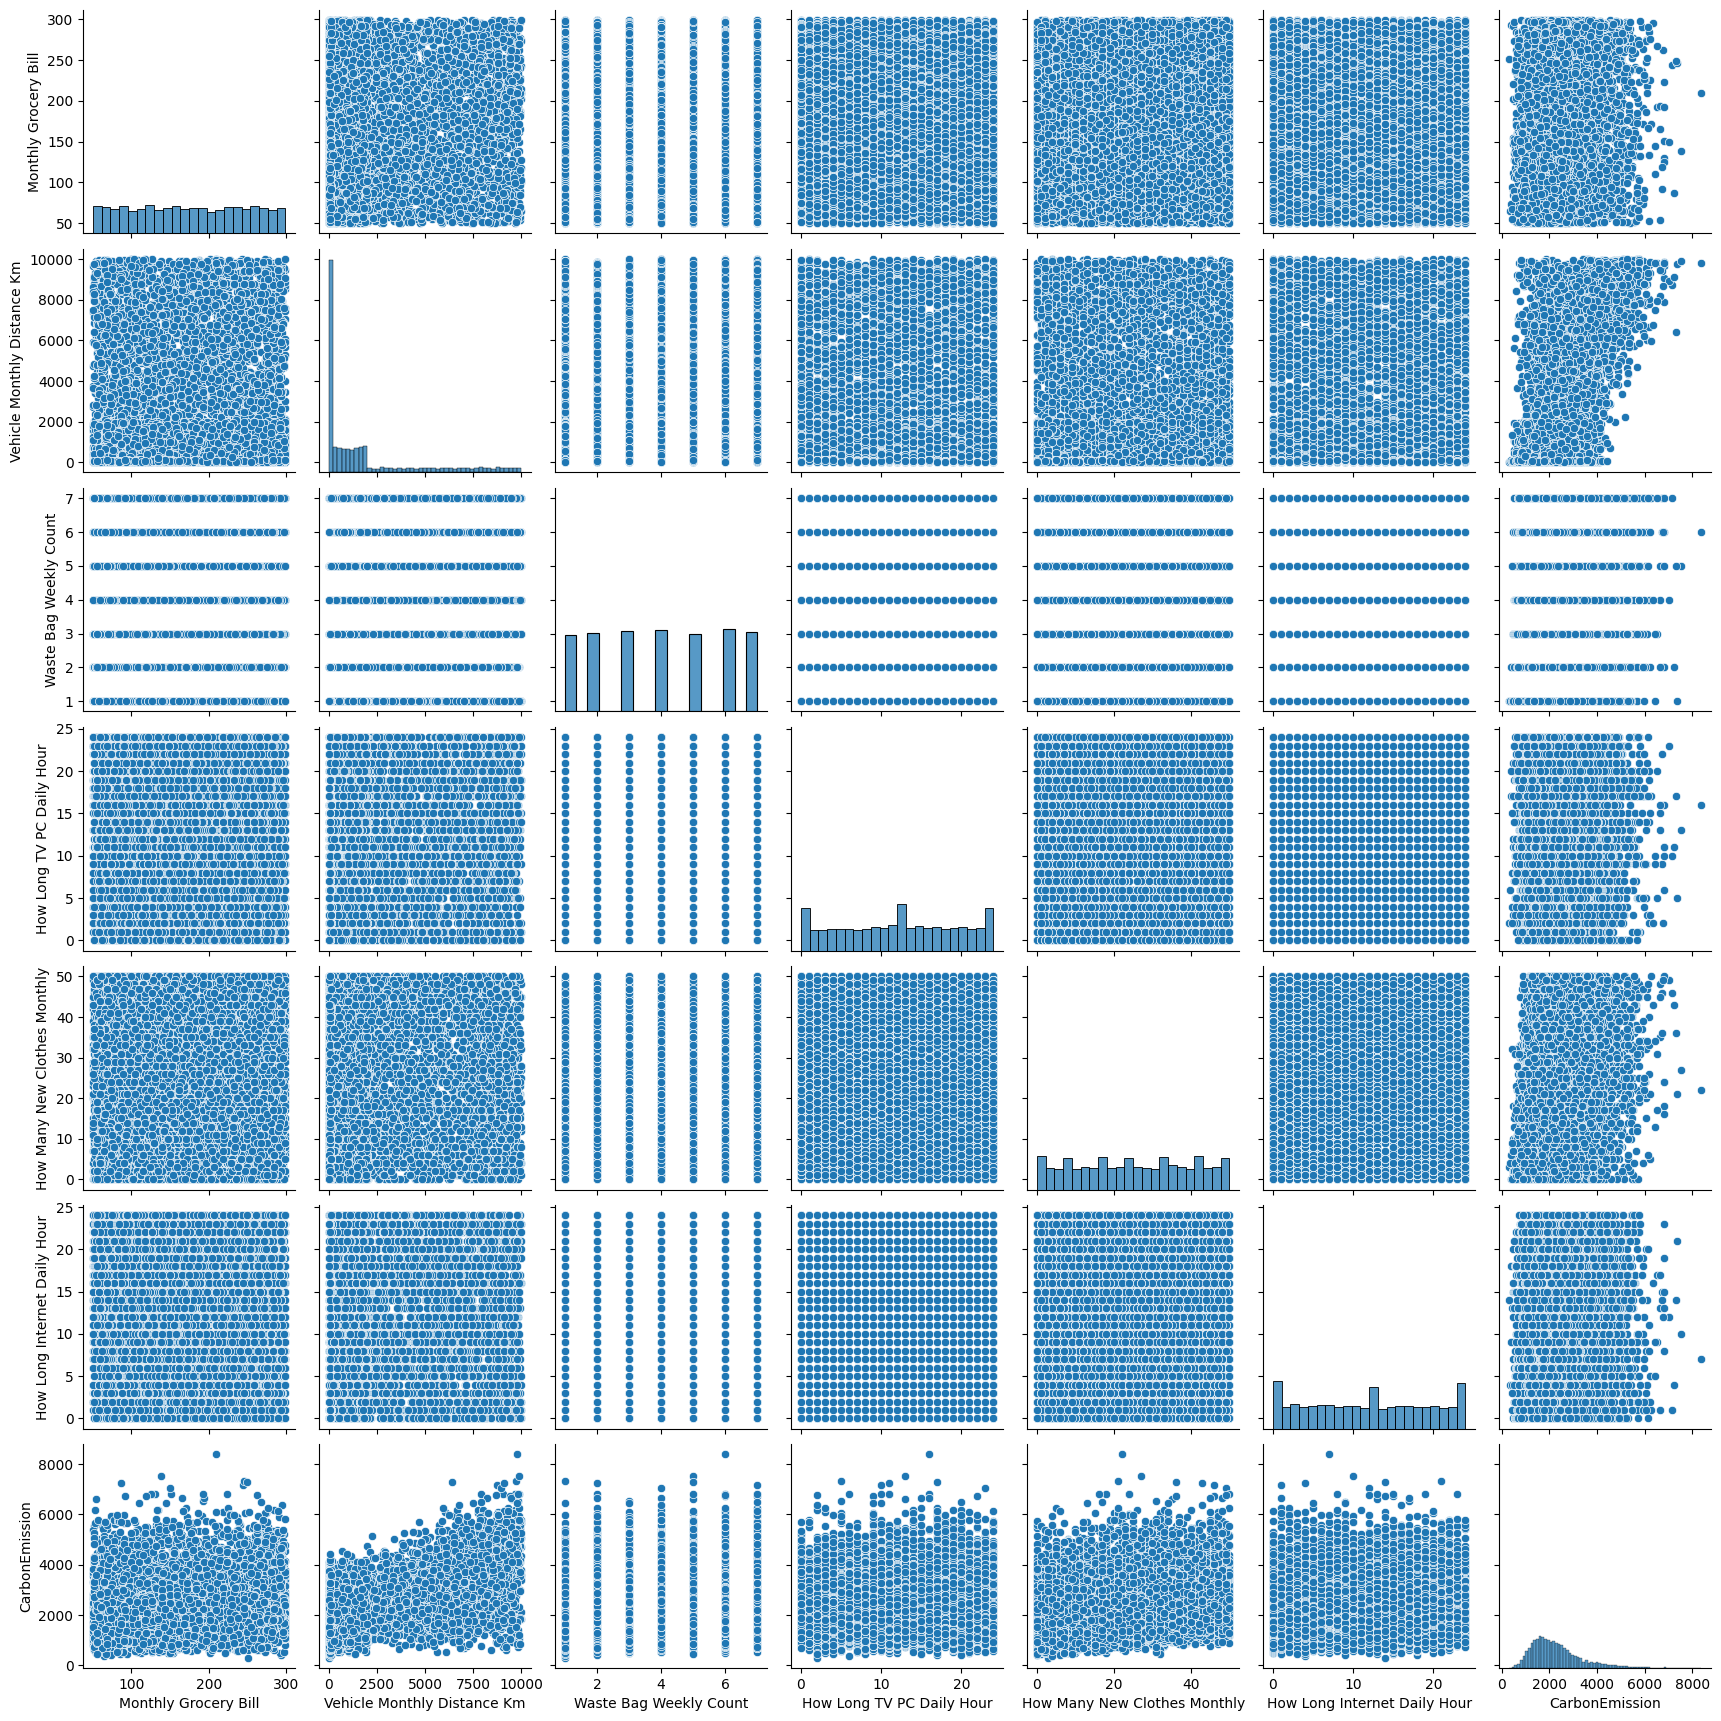

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Carbon Emission.csv")

# Basic info
print(df.info())
print(df.describe())

# -------------------------
# Distribution Plot
# -------------------------
plt.figure()
df["CarbonEmission"].hist(bins=30)
plt.title("Carbon Emission Distribution")
plt.xlabel("Carbon Emission")
plt.ylabel("Frequency")
plt.show()

# -------------------------
# Correlation Heatmap
# -------------------------
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure()
corr = numeric_df.corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# -------------------------
# Pairplot (Feature Analysis)
# -------------------------
sns.pairplot(numeric_df)
plt.show()

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Features & Target
X = df.drop(columns=["CarbonEmission"])
y = df["CarbonEmission"]

# Column types
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# Model Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


MAE: 217.5831
RMSE: 285.90132112181647
R² Score: 0.9183356303993089


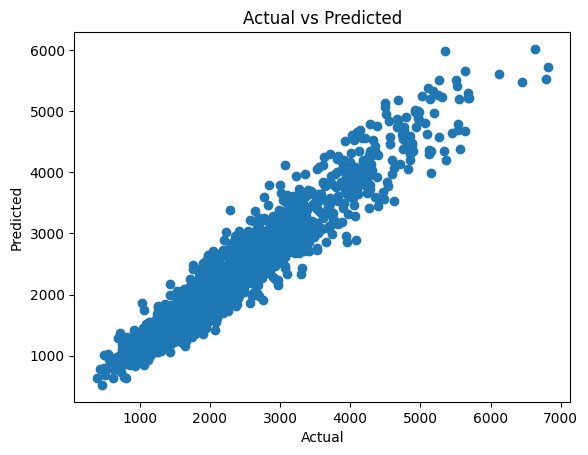

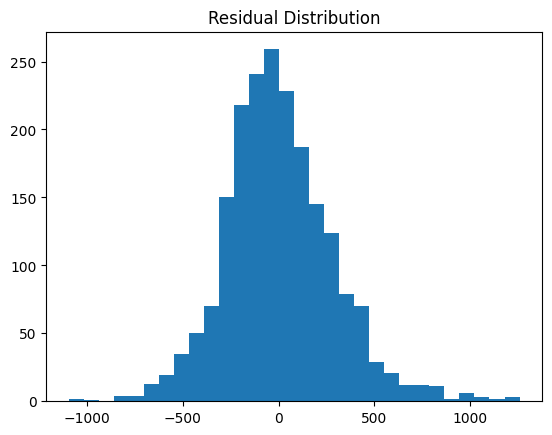

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

# -------------------------
# Actual vs Predicted Plot
# -------------------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# -------------------------
# Residual Plot
# -------------------------
residuals = y_test - y_pred

plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

,Model,MAE,RMSE,R2
0,LinearRegression,776.847213,1001.257979,-0.001595
1,RandomForestRegressor,797.105593,1019.037697,-0.037483


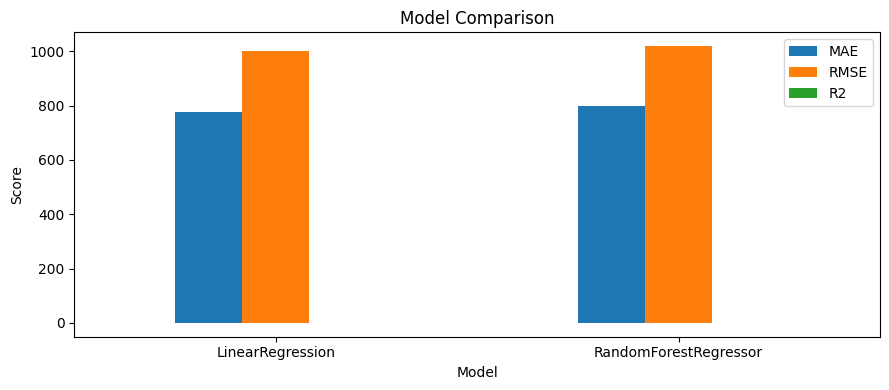

In [53]:
# Model comparison: LinearRegression vs RandomForestRegressor

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If scaled data exists, use it; otherwise fall back to raw train/test data
if "X_train_scaled" in globals() and "X_test_scaled" in globals():
    Xtr, Xte = X_train_scaled, X_test_scaled
else:
    Xtr, Xte = X_train, X_test

models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
display(results_df)

# Simple visualization
ax = results_df.set_index("Model")[["MAE", "RMSE", "R2"]].plot(
    kind="bar", figsize=(9, 4), rot=0, title="Model Comparison"
)
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()